# Background

Author: Diane Menuz  
Date: 2026-05-29    
  
Goal: Create daily crop height estimates for alfalfa, using example from Wellington.

Required inputs
1. Daily mean, min, and max temperature data for full year(s) of analysis. In this  
example, data were obtained climate data from https://prism.oregonstate.edu/explorer/.  
You can run the crop height function without climate data, but this example relies on  
growing degree days which must be calculated with continuous daily climate data.
2. Field-measured crop height. Ideally at least four or five data points per year.
3. Estimates of cut dates for alfalfa. These can be obtained from reviewing timelapse  
footage, producer information, or through an optional analysis of NDVI data.
4. General idea of spring green-up and fall die-back dates, from photos or timelapse  
imagery. The model usually does a good job estimating when green-up occurs based on  
growing-degree days, but sometimes the model shows the field starting to grow too early.  
More often, the model will show the crop continuing to grow further into the winter than  
what photos show. You can adjust parameters in the model to compensate if the model does  
not do a good job estimating these dates.

# Crop Height Estimation

## Setup and Initial Parameters

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../../../src')
from micromet import eddy_plots as ed_plot
from micromet import simulate_alfalfa_height_single_field,  AlfalfaHeightParams
from micromet import generate_field2_heights

In [19]:
stationid = 'US-UTW' 
zone = 'SE' # identifier for main field where height will be estimated
# optional name of second field
# this is a field managed similarly to the first field, but with the crop cut a few days  
# earlier or later than the first field
zone_secondary = 'N'

In [20]:
# field-measured crop height from the main 'zone'
field_heights_dict = {
 '2023-04-26': 3.0,
 '2023-06-05': 64.9,
 '2023-07-18': 60.0,
 '2023-08-02': 6.1,
 '2023-08-31': 53.3,
 '2023-09-19': 13.1,
 '2023-10-24': 21.9,
 '2024-04-01': 6.1,
 '2024-05-16': 29.9,
 '2024-06-06': 48.8,
 '2024-06-19': 61.0,
 '2024-06-27': 6.1,
 '2024-07-23': 39.9,
 '2024-08-09': 67.1,
 '2024-08-22': 60.0,
 '2024-09-15': 14.9,
 '2024-10-08': 43.3,
 '2024-12-11': 3.0
 }

field_height = pd.Series(field_heights_dict, name='height_cm').to_frame()       
field_height.index = pd.to_datetime(field_height.index)

## Optional- Cut Dates from NDVI

Results from pivot_ndvi_analysis can be used to identify or confirm field cut dates.  
One of the outputs of this analysis is a list of cut dates by year. These should be  
confirmed against the timeseries of NDVI data, crop height data, and camera images if  
possible. Cut will generally have a steep drop in NDVI. Late-season gradual die-off or  
cattle grazing will show a more gradual decrease in crop height.  
  
Regardless of whether you use NDVI or another method, you must identify cut dates for  
both the primary and, if present, the secondary field.


In [29]:
# read in ndvi data
cutting_file = f"../sample_data/{stationid}_pivot_cut_events.csv"
ndvi_file = f'../sample_data/{stationid}_pivot_ndvi_multizone_long.csv'
ndvi_cuttings = pd.read_csv(cutting_file, parse_dates=['cut_date'], index_col='cut_date')
ndvi_cuttings['ndvi_cut'] = 50
ndvi_height = pd.read_csv(ndvi_file, parse_dates=['date'], index_col='date')

In [30]:
# review 
zone1 = ndvi_height[ndvi_height.zone==zone]
cut1 = ndvi_cuttings[ndvi_cuttings.zone==zone]

ed_plot.plotlystuff([zone1,cut1,  field_height], 
                    ['height_median_cm','ndvi_cut','height_cm'],
                     chrttypes= ['lines','markers', 'markers'],
                     chrttitle=zone)

In [31]:
# review cut dates for main zone and modify in dictionary as needed
zone2 = ndvi_height[ndvi_height.zone==zone_secondary]
cut2 = ndvi_cuttings[ndvi_cuttings.zone==zone_secondary]

ed_plot.plotlystuff([zone2,cut2,  field_height], 
                    ['height_median_cm','ndvi_cut','height_cm'],
                     chrttypes= ['lines','markers', 'markers'],
                     chrttitle=zone)

In [10]:
# list of final cut dates for each field
cuts = [
        "6/24/2023",
        "7/27/2023",
        "9/7/2023", 
        "6/24/2024",
        "8/28/2024",
        "11/3/2024",
]

cut_dates_secondary = [
        "6/24/2023", 
        "7/27/2023", 
        "9/7/2023", 
        "6/24/2024",
        "8/27/2024",
        "11/3/2024"
]

## Test Parameters and Finalize Model

In [32]:
# format weather data
prism_data = f"../sample_data/{stationid}_prism_20230101_20251130.csv"
daily_weather = pd.read_csv(
    prism_data, skiprows=10, parse_dates=['Date'], index_col='Date')
daily_weather['tmean_c'] = (daily_weather['tmean (degrees F)']-32)*5/9
daily_weather['tmin_c'] = (daily_weather['tmin (degrees F)']-32)*5/9
daily_weather['tmax_c'] = (daily_weather['tmax (degrees F)']-32)*5/9
daily_weather['ppt'] = (daily_weather['ppt (inches)']*25.4)

Set model parameters for each each.  You could optionally just set the parameters  
directly in the model parameters, below, but these are the parameters that most often  
need to be adjusted. The parameters, in order, are:
- first date of model: I suggest starting with March 15 or 30th and adjusting as needed.  
Most of the time, the model won't show any growth until after this date because things  
are too dry. However, sometimes growth starts early in March. If this conflicts with  
site photos or other data, you can move the start date to when green-up actually started.
- last date of model: Again, I recommend starting with mid to late November. Often the  
model will not have any alfalfa growth after the last cut or will naturally ramp down.  
However, sometimes you need to estimate the date that the crop is cut down from cameras  
or other sources because sometimes the model shows the crop growing throughout the  
winter (which I have not seen corroborated in imagery)
- k rates: List of one or more k-rates. K rates are applied in order before and between  
each cutting period. If there isn't a rate for a particular cutting period, the script  
will default back to the last k rate. I recommend starting with a single value and then  
adjusted as needed. I often found that the k rate in the first period is higher than  
subsequent periods. In the absence of good data to anchor the k rate, I recommend either  
defaulting to the previous period's k rate or trying to get the crop height to about the  
same max height as other time periods. 
- grazing parameter: This can be listed as None or a list of maximum height values to  
set the crop at during periods of grazing (e.g., None or [None, None, 25] if the period  
after the last cut should be set to a max height of 25 cm). This is useful during times  
when cattle are growing the crop and it isn't growing a lot. Sometimes I can simulate  
this well just by adjusting fall k rates, but sometimes I need to add in the grazing  
parameter, particularly when grazing starts earlier in the summer.

In [33]:
# set model parameters
site_params = {
    2023: ['2023-03-30', '2023-11-15', [0.009, 0.006,0.003, 0.001], None],
    2024: ['2024-03-30', '2024-11-15', [0.007,0.002], None]
}

In [34]:
# run height estimates
height_estimates = []
years = list(site_params.keys())
for year in years:
    year_params = site_params[year]

    model_params= AlfalfaHeightParams(
        h_resid_cm=5,
        h_max_cm=75.0,
        rate=year_params[2],  
        model="exp",
        time_mode="gdd",
        tbase_c= 10.0,
        tcap_c=30,      
        dormancy_mode="temp",
        grazing_height = year_params[3],
        tmean_col="tmean_c",
    )


    modeled_height = simulate_alfalfa_height_single_field(
        dates= pd.date_range(year_params[0], year_params[1], freq="D"),
        cut_dates = cuts,
        params = model_params,
        weather = daily_weather,
        cut_effect= "post")  # 'post' means height on cut date is stubble
    modeled_height = pd.DataFrame(modeled_height) 
    height_estimates.append(modeled_height)

# create dataframe for full year
start_date = f'{pd.Series(years).min()}-01-01'
end_date = f'{pd.Series(years).max()}-12-31'
final_heights = pd.concat(height_estimates)
full_calendar = pd.date_range(
    start=pd.to_datetime(start_date), 
    end= pd.to_datetime(end_date), 
    freq="D"
)

final_heights = final_heights.reindex(full_calendar)
final_heights['stationid'] = stationid
final_heights['zone_name'] = zone
final_heights.index.name = 'height_date'
final_heights['height_cm'] = final_heights['height_cm'].fillna(model_params.h_resid_cm)
final_heights['height_m'] = final_heights['height_cm']/100
final_heights['measurement_type'] = 'exp gdd model'

Mean height difference between field and model heights in cm: -0.7
Mean absolute height difference between field and model heights in cm: 4.5


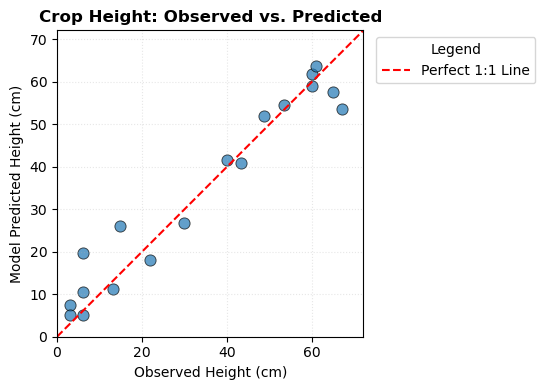

In [15]:
# review results 
merged = pd.merge_asof(field_height, final_heights, left_index=True, right_index=True,
                               tolerance=pd.Timedelta('3day'), direction='nearest', 
                               suffixes=['_field', '_model'])
merged['height_diff'] = merged['height_cm_field'] - merged['height_cm_model']
print(f'Mean height difference between field and model heights in cm: {
    merged.height_diff.mean().round(1)}')
print(f'Mean absolute height difference between field and model heights in cm: {
    merged.height_diff.abs().mean().round(1)}')

ed_plot.plotlystuff([final_heights, field_height],
                    ['height_cm','height_cm'],
                    ['lines', 'markers'],
                    plot_height = 300)

plt.figure(figsize=(5.5, 4))

sns.scatterplot(
    data=merged,
    x='height_cm_field',
    y='height_cm_model',
    alpha=0.7,
    edgecolor='black',
    s=65
)

max_val = max(merged['height_cm_field'].max(), merged['height_cm_model'].max())
plt.plot(
    [0, max_val + 5], 
    [0, max_val + 5], 
    color='red', 
    ls='--', 
    lw=1.5, 
    label='Perfect 1:1 Line'
)
plt.title('Crop Height: Observed vs. Predicted', fontsize=12, fontweight='bold')
plt.xlabel('Observed Height (cm)', fontsize=10)
plt.ylabel('Model Predicted Height (cm)', fontsize=10)

plt.xlim(0, max_val + 5)
plt.ylim(0, max_val + 5)
plt.gca().set_aspect('equal', adjustable='box')

plt.grid(True, alpha=0.3, ls=':')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), title='Legend')

plt.tight_layout()
plt.show()

## Optional Heights for Secondary Field

Option to develop a dataframe of crop heights for a second field that is managed very  
similarly to the first field, but with cuts one or a few days apart. Crop height in the  
second field will be set to the same height as the first field each day except during  
the period when one is cut before the other. If the secondary field is cut first, the  
crop height on that field will be set to the h_resid_cm value until the second field is  
cut.If the primary field is cut first, the secondary field height will be set to the max  
height of the primary field right before the cut until the secondary field is cut.  
  
In the example below, the only difference in cut date is 2024-08-27, where cuts were  
offset by one day.

In [16]:
# model for secondary cuts
secondary_heights = generate_field2_heights(
    field1_data=final_heights['height_cm'],
    field1_cuts = cuts,
    field2_cuts = cut_dates_secondary,
    h_resid_cm = 5,
    catchup_days = 15
)

secondary_heights = pd.DataFrame(secondary_heights)

secondary_heights['stationid'] = stationid
secondary_heights['zone_name'] = zone_secondary
secondary_heights.index.name = 'height_date'
secondary_heights['height_m'] = secondary_heights['height_cm']/100
final_heights['measurement_type'] = 'exp gdd model secondary field'

ed_plot.plotlystuff([final_heights, secondary_heights],
                    ['height_cm', 'height_cm'])

# Export Final Data

Export final data including:
- primary height data
- secondary height data
- cut dates for primary and secondary fields
- parameters used in the gdd model